In [61]:
import numpy as np
# import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
import scienceplots 
plt.style.use('science')

import os
import shutil

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
print("PATH:", os.environ.get("PATH"))
print("pdflatex:", shutil.which("pdflatex"))

PATH: /Users/turtle/miniconda3/envs/bmc/bin:/Users/turtle/.local/bin:/Users/turtle/miniconda3/envs/bmc/bin:/Users/turtle/miniconda3/condabin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/pmk/env/global/bin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin:/Library/TeX/texbin
pdflatex: /Library/TeX/texbin/pdflatex


In [62]:
%reload_ext autoreload
%autoreload 2
from config import models, fy_added_models, colors_sets, alpha_train, alpha_test, alpha_validation, color_train, color_test, color_validation, size_train, size_test, size_validation, marker_train, marker_test, marker_validation
from data_loading import load_charge_radii, load_charge_radii_fy
from pre_processing import filtered_NZ_extraction, unified_NZ_extraction, selected_models_data_sets_extraction, models_output_extraction, filtered_models_output_extraction, filtered_models_output_dict_extraction, filtered_models_output_stable_extraction
from splitting import new_split 
from plot import plot_singular_values, plot_model_predictions, plot_pc_rmse_curve, plot_bmc_error_heatmap_scatter, plot_filtered_supermodel, plot_filtered_supermodel_simplex, plot_coverage
from metrics import pc_rmse_curve, rndm_m_random_calculator, coverage
from samplers import gibbs_sampler
from prediction import build_bmc_error_dataframe, build_filtered_outputs_per_Z, BMCPredictor, build_bmc_intervals_per_Z

In [63]:
# Load experimental data
CR_experimental = load_charge_radii("../../data/charge_radii.csv")
bailey_data = load_charge_radii_fy("../../data/nuclei_min_energies_2.csv", output_col='Fy_Dr')
Fy_IVP = load_charge_radii_fy("../../data/fyivp_nuclei_min_energies.csv", output_col='Fy_IVP')

models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("../../data/selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}
filtered_NZ = np.array([models_data_sets[models[0]]['N'].tolist(), models_data_sets[models[0]]['Z'].tolist() ]).T
stable_coordinates_full=np.loadtxt("../../Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models, filtered_NZ)

In [64]:
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models, filtered_NZ_df, 'ChRad')
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, bailey_data[['N', 'Z',  'Fy_Dr']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, Fy_IVP[['N', 'Z',  'Fy_IVP']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, CR_experimental[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values


In [65]:
models = fy_added_models.copy()

In [66]:
train_coordinates_radius, val_coordinates_radius, test_coordinates_radius = new_split(selected_models_data_sets_radius)
train_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[train_coordinates_radius].values
val_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[val_coordinates_radius].values
test_set_radius = selected_models_data_sets_radius[['N', 'Z']].iloc[test_coordinates_radius].values

models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, val_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [67]:
filtered_models_output_radius_list_20 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (20,20))

filtered_models_output_radius_list_28 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (28,28))

filtered_models_output_radius_list_50 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (50,50))

filtered_models_output_radius_list_80 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (80,80))

filtered_models_output_radius_list_82 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (82,82))
filtered_models_output_radius_list_40 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (40,40))

filtered_models_output_radius_list_96 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (96,96))



model_predictions_radius=models_output_radius[models].values
model_predictions_radius_train=models_output_radius_train[models].values
model_predictions_radius_validation=models_output_radius_validation[models].values
model_predictions_radius_test=models_output_radius_test[models].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

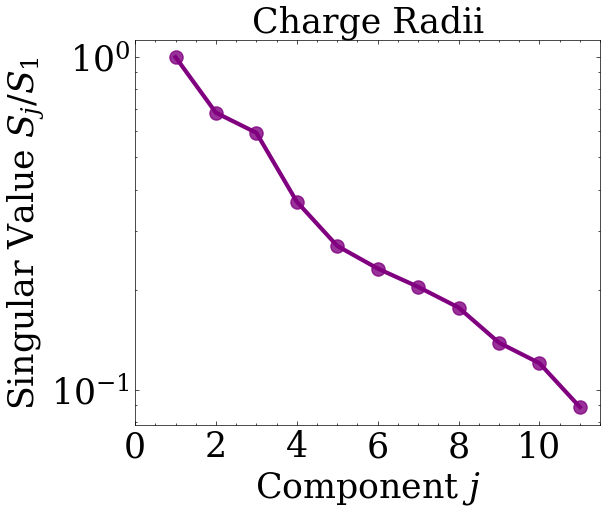

In [34]:
centering_data = True

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]

U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)
plot_singular_values(S, "Charge Radii")

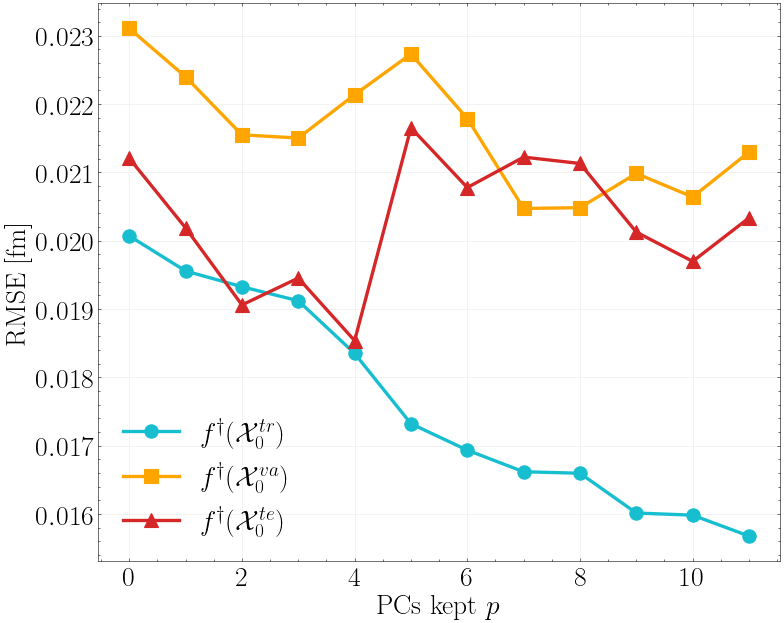

In [68]:
rmse_df = pc_rmse_curve(
    train_df=models_output_radius_train,
    val_df=models_output_radius_validation,
    test_df=models_output_radius_test,
    full_df=models_output_radius,
    model_cols=models,
    Vt=Vt,
    truth_col='truth',
    max_components=len(models)-1
)
plot_pc_rmse_curve(
    rmse_df,
    title='', 
    dpi=80
)
plt.savefig('../pp_plots/fy_added_models/PC_RMSE_Curve.png')

In [36]:
components_kept = 4
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

X_train = U_hat.copy()
nu0_chosen=1
sigma20_chosen=0.01

samples = gibbs_sampler(y_radius, X_train, 50000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

In [37]:
Z_values = sorted(models_output_radius['Z'].unique())
# 1) build filtered slices once
per_Z_radius = build_filtered_outputs_per_Z(
    models_output=models_output_radius,
    train_idx=train_coordinates_radius,
    val_idx=val_coordinates_radius,
    test_idx=test_coordinates_radius,
    stable_coordinates_df=stable_coordinates_radius_df,
    Z_values=Z_values,
    N_range=(0, 300)
)

# 2) build predictor once
predictor = BMCPredictor(samples=samples, Vt_hat=Vt_hat, n_draws=50000, seed=142858)

# 3) compute BMC intervals per Z
# IMPORTANT: model_cols must match the model order used when constructing Vt_hat  # or whatever ordering Vt_hat expects
bmc_per_Z = build_bmc_intervals_per_Z(per_Z_radius, predictor, models)


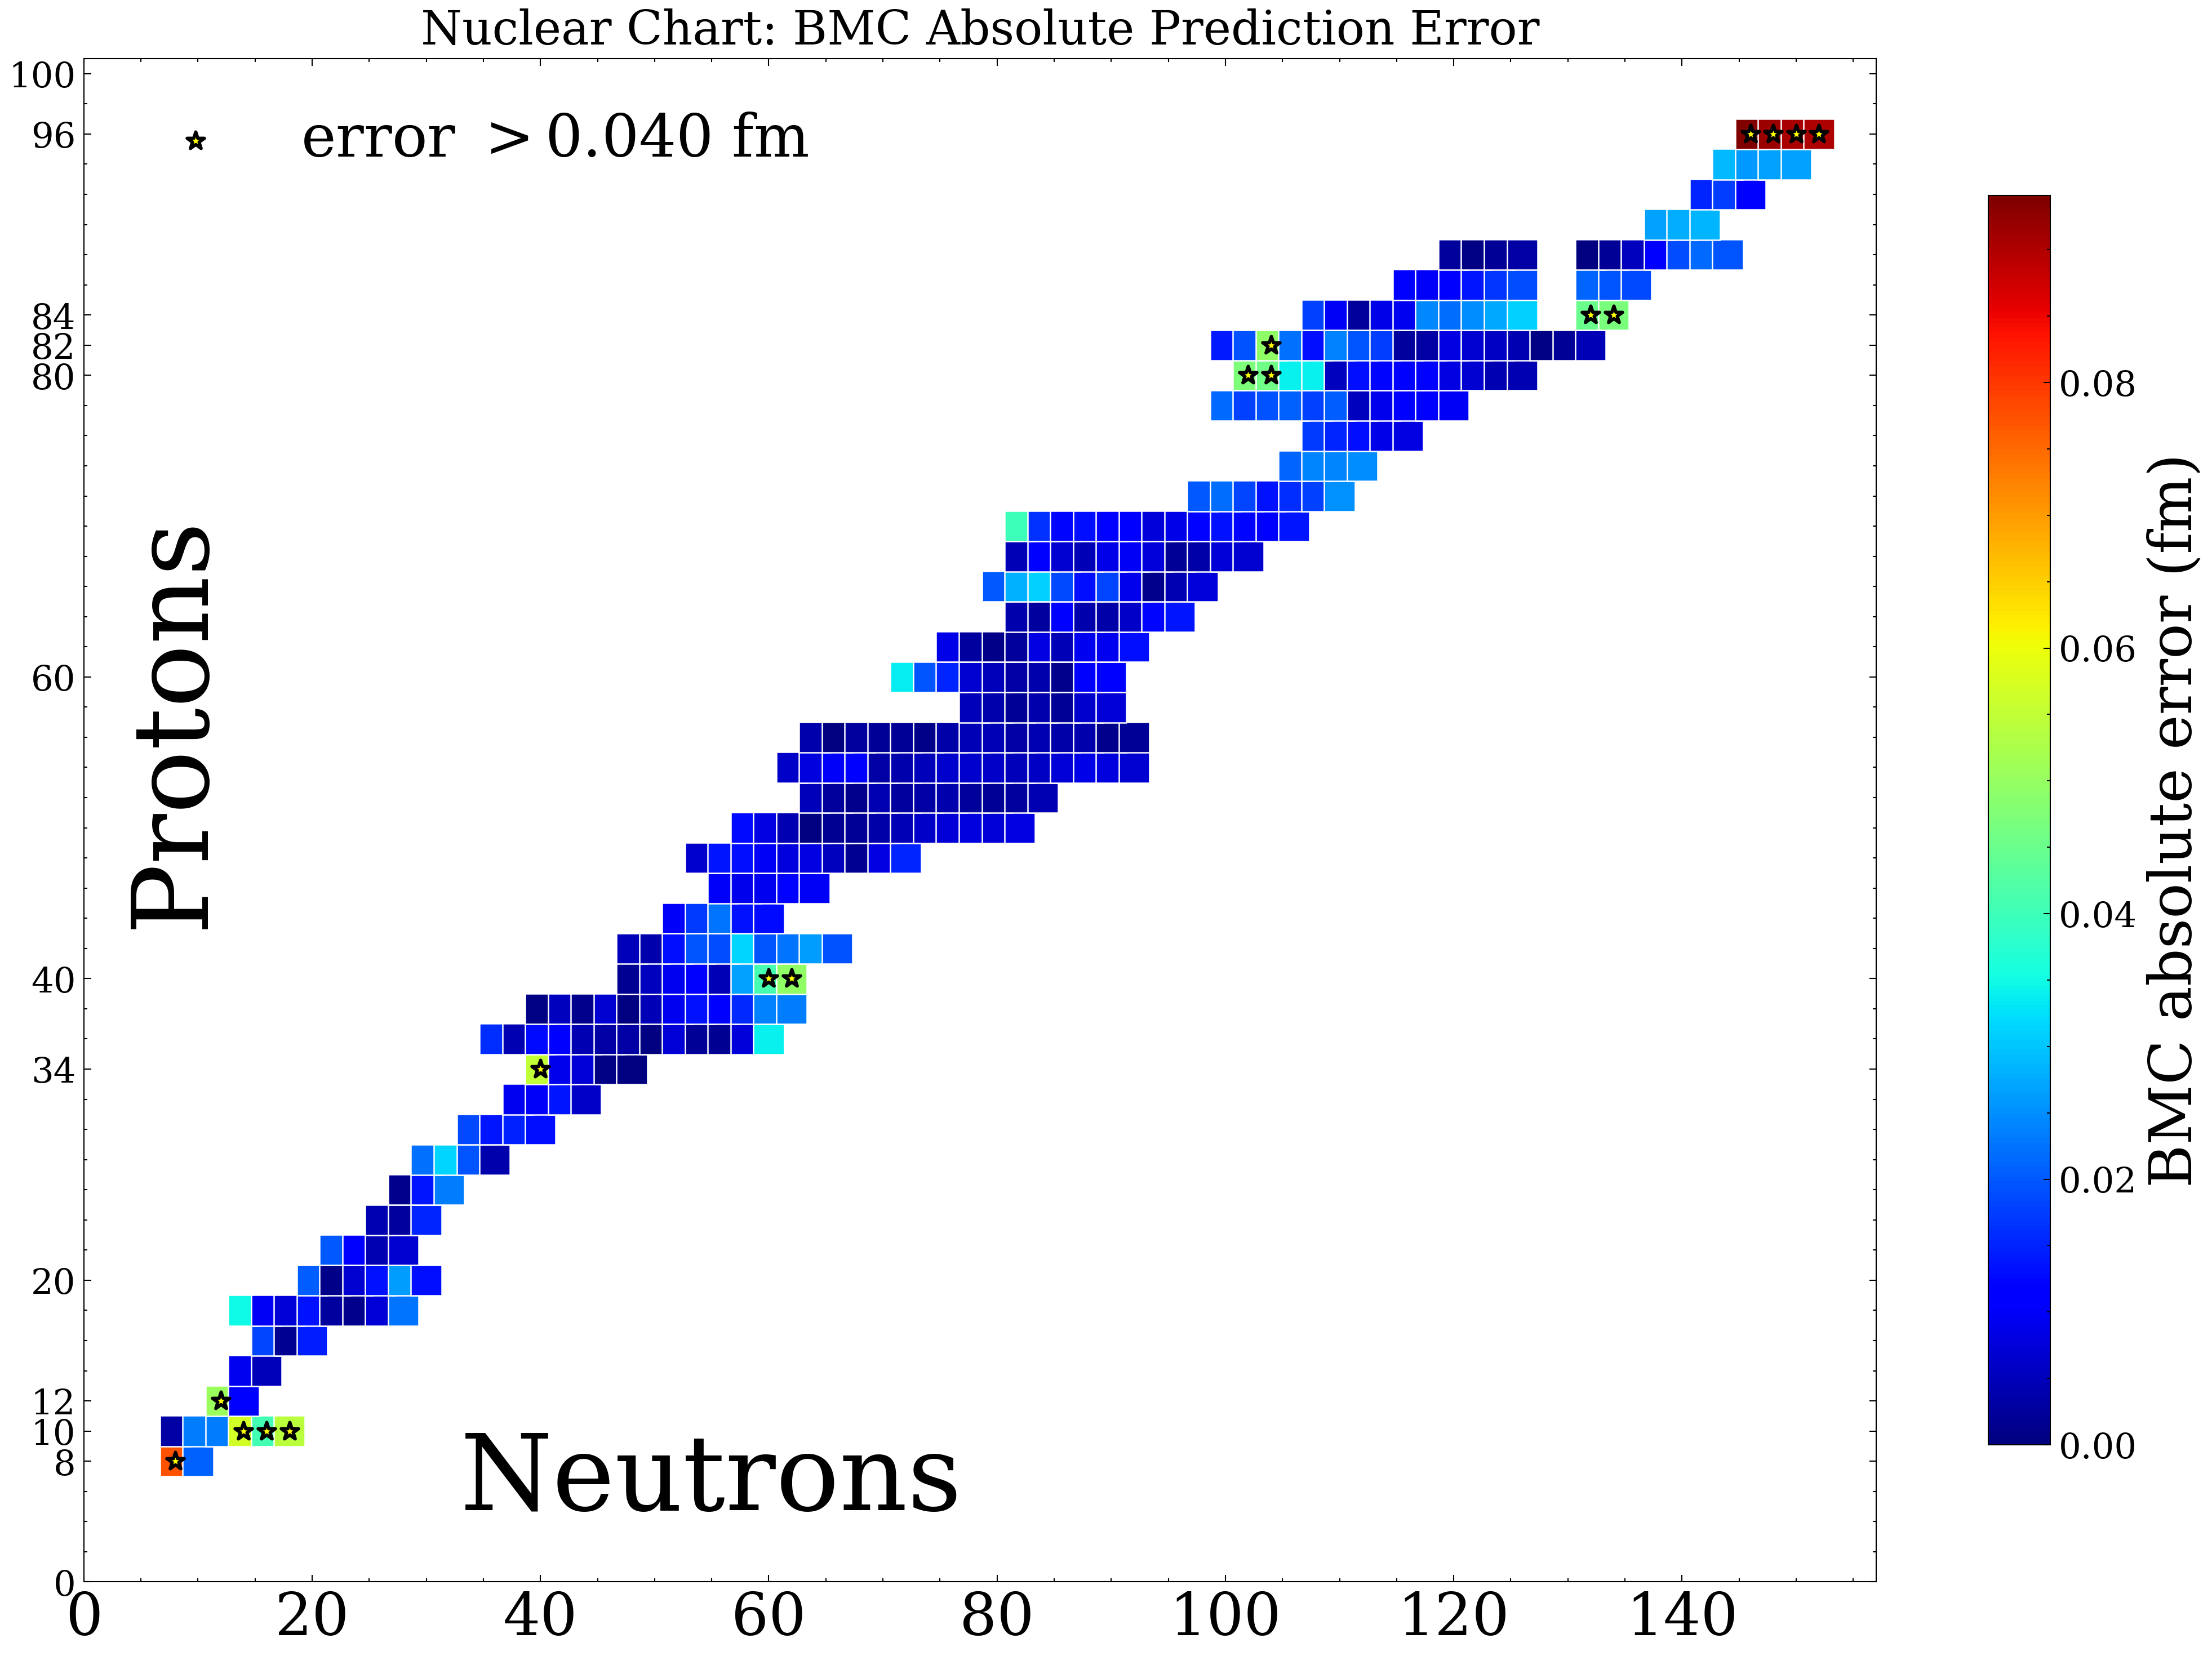

In [40]:
error_df = build_bmc_error_dataframe(per_Z_data=per_Z_radius, bmc_per_Z=bmc_per_Z, truth_col='truth')
plot_bmc_error_heatmap_scatter(error_df, threshold=0.04, cmap='jet', absolute_error=True)
plt.savefig('../pp_plots/fy_added_models/BMC_error_heatmap_absolute_metric.png')

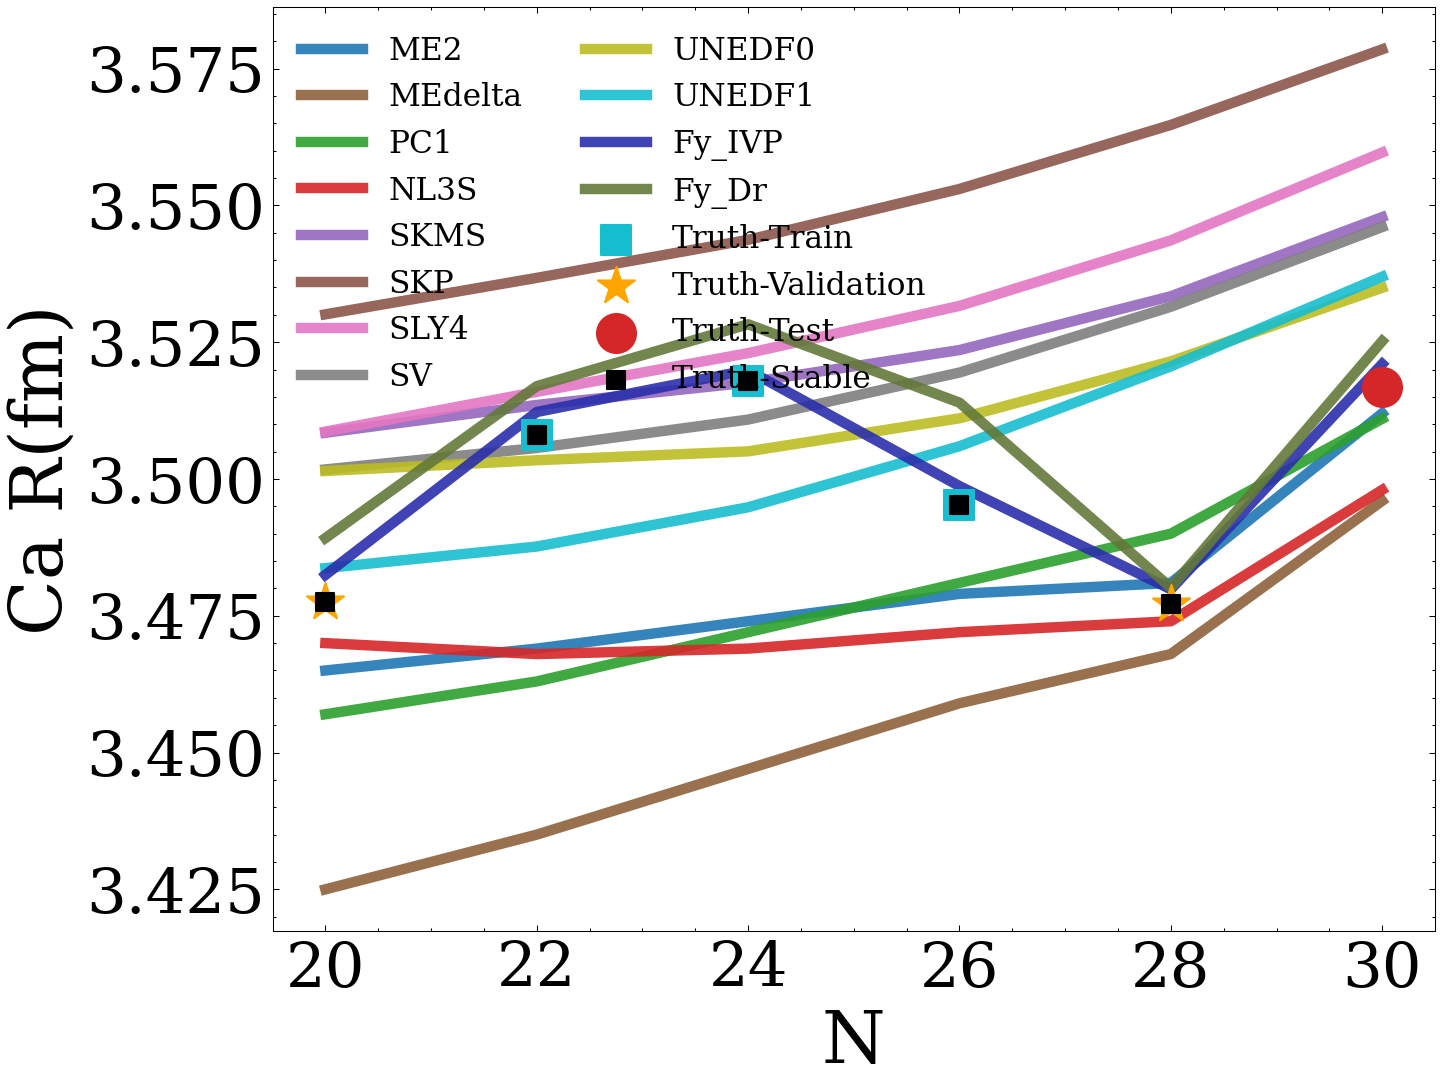

In [43]:
filtered_models_output_radius_list_20 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (20,20))
plot_model_predictions(filtered_models_output_radius_list_20, models, 'Ca')
plt.savefig('../pp_plots/fy_added_models/Ca_model_predictions.png')
plt.show()

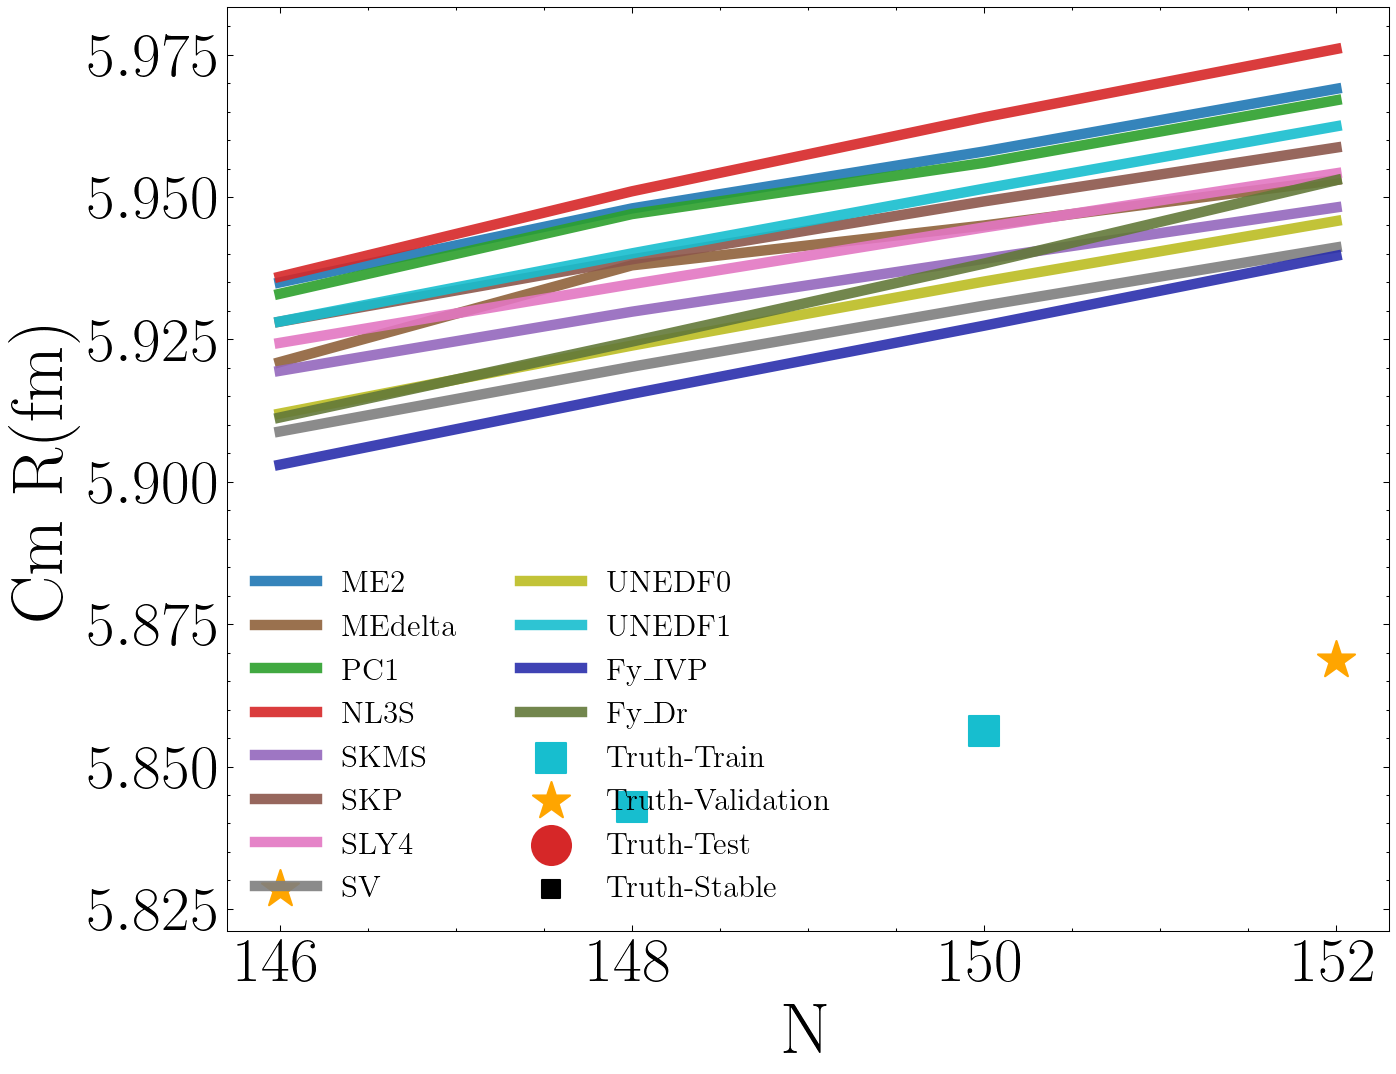

In [59]:
filtered_models_output_radius_list_96 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (96,96))
plot_model_predictions(filtered_models_output_radius_list_96, fy_added_models, 'Cm')
plt.savefig('../pp_plots/fy_added_models/Cm_model_predictions.png')
plt.show()

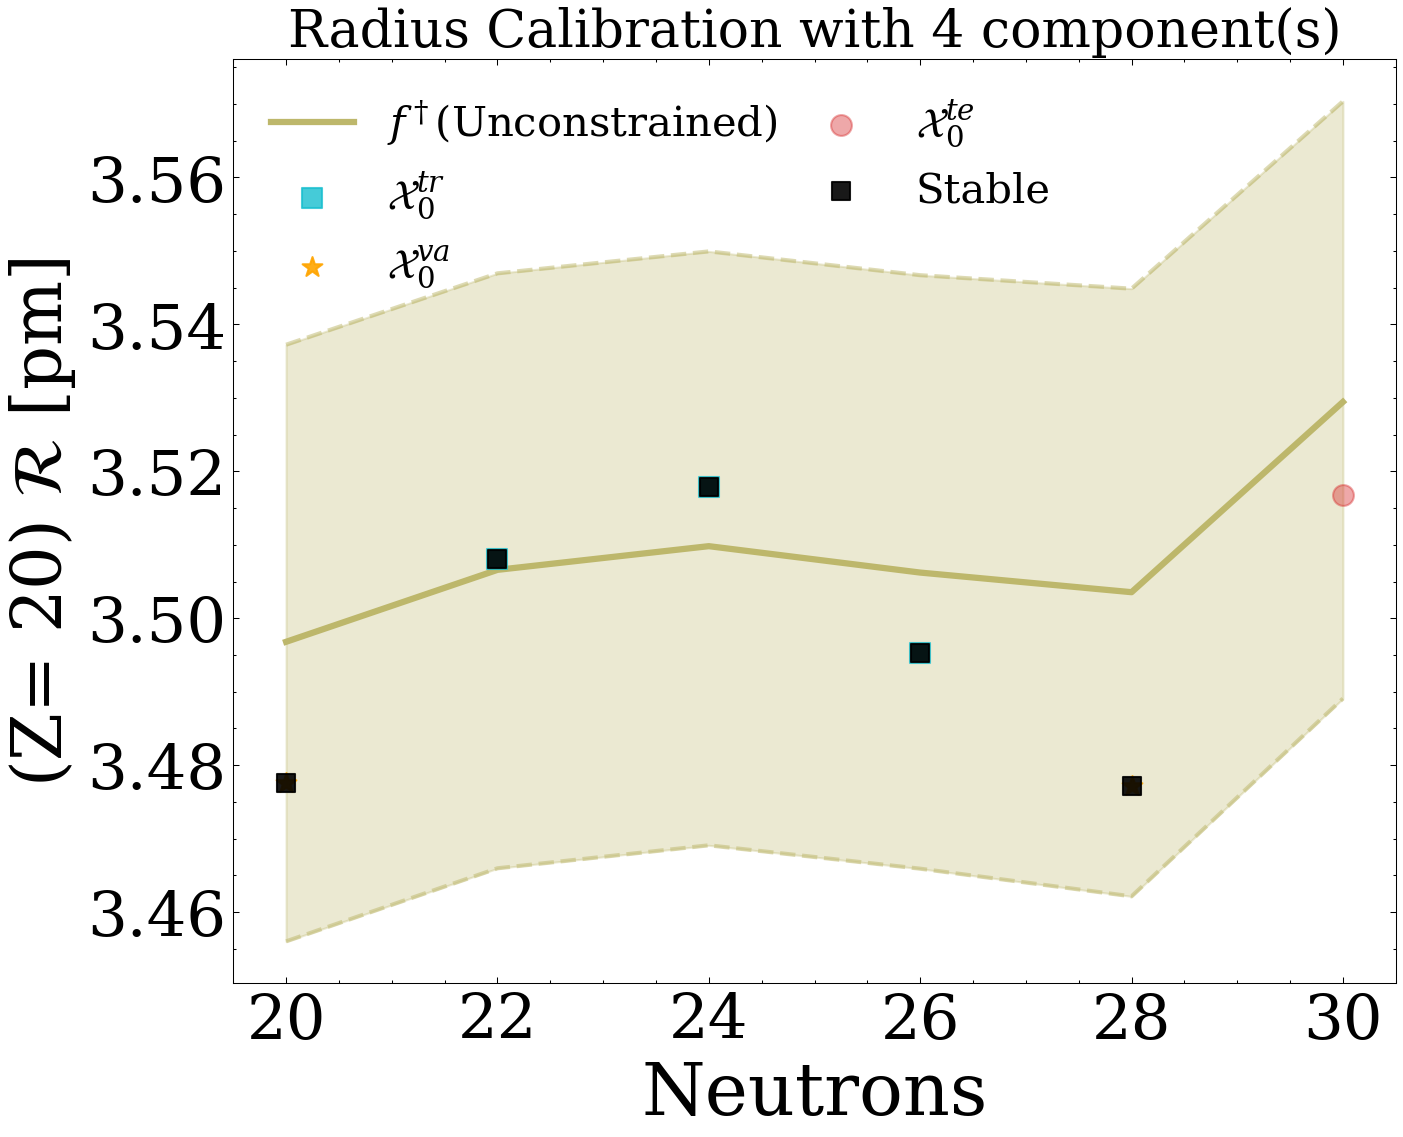

In [49]:
filtered_models_output_radius_list_20 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (20,20))
filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

rndm_20, [lower_radius_20, median_radius_20, upper_radius_20] = rndm_m_random_calculator(filtered_model_predictions_radius_20, samples, Vt_hat)
supermodel_predictions_radius_range_20 = [lower_radius_20, median_radius_20, upper_radius_20]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_20, filtered_models_output_radius_list_20, 20, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig('../pp_plots/fy_added_models/Ca_20_Unconstrained _BMM_with_4_components.png')
plt.show()

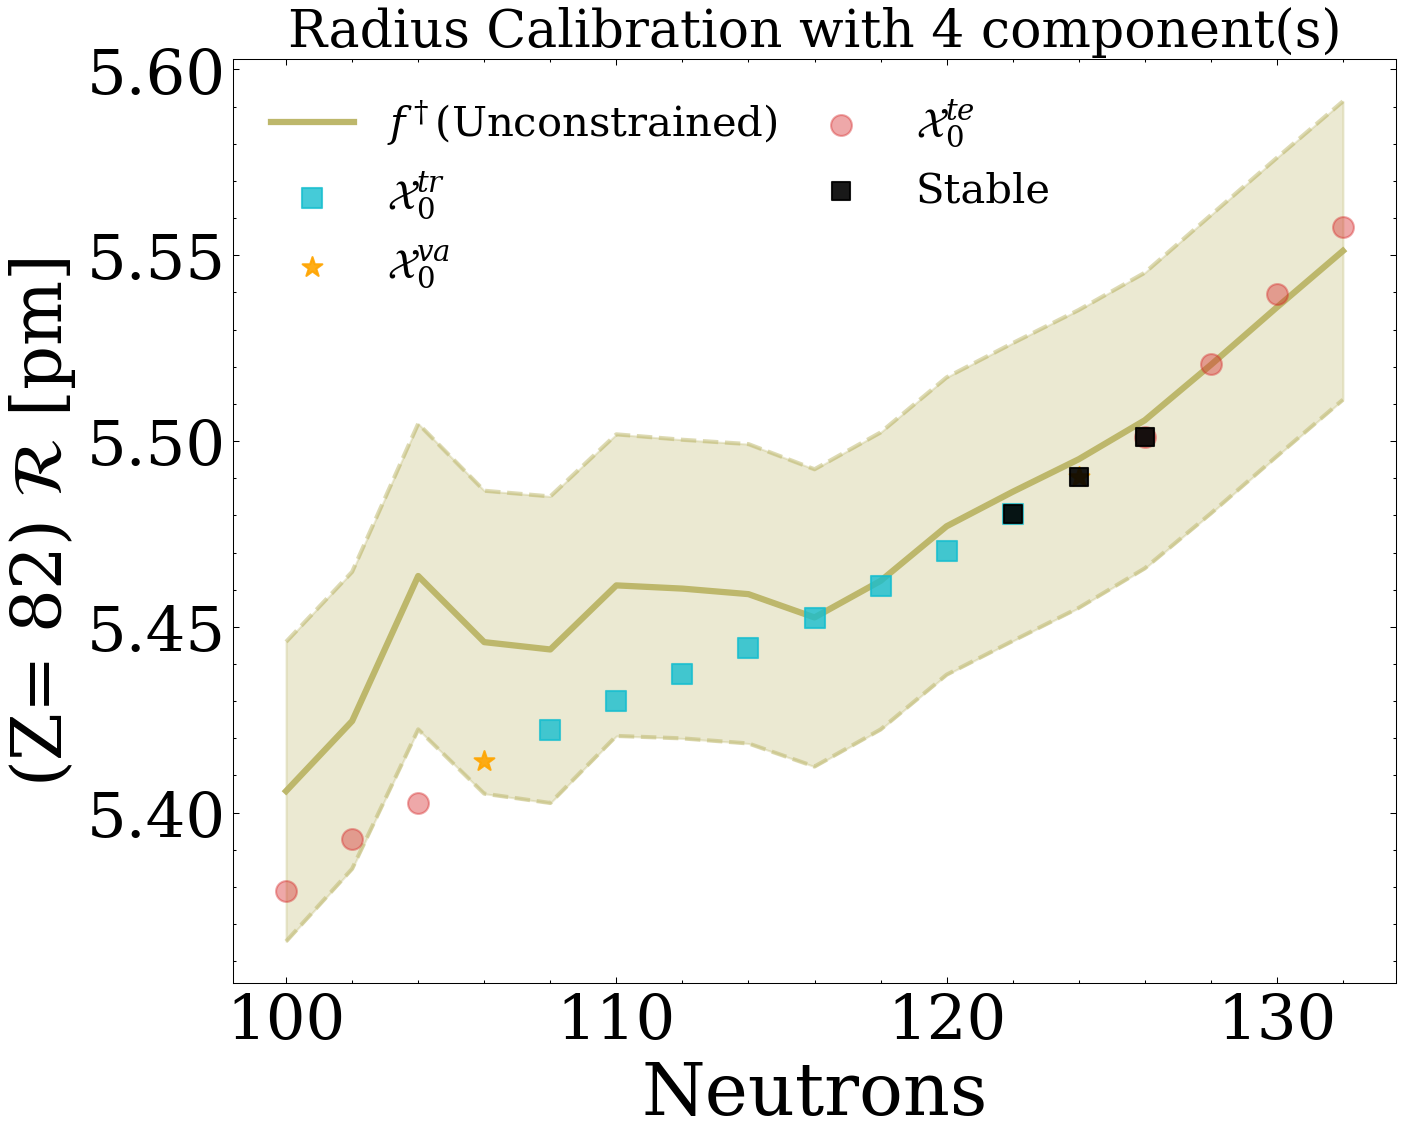

In [50]:
filtered_models_output_radius_list_82 = filtered_models_output_extraction(models_output_radius, \
                                        train_coordinates_radius, val_coordinates_radius, \
                                        test_coordinates_radius, stable_coordinates_radius_df, (82,82))
filtered_models_output_radius_82 = filtered_models_output_radius_list_82[0]
filtered_model_predictions_radius_82 = filtered_models_output_radius_82.iloc[:,3:-1].values

rndm_82, [lower_radius_82, median_radius_82, upper_radius_82] = rndm_m_random_calculator(filtered_model_predictions_radius_82, samples, Vt_hat)
supermodel_predictions_radius_range_82 = [lower_radius_82, median_radius_82, upper_radius_82]
# title = 'Radius Calibration'
# savefig_82_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 82 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_82, filtered_models_output_radius_list_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig('../pp_plots/fy_added_models/Pb_82_Unconstrained _BMM_with_4_components.png')
plt.show()

In [54]:
rndm_total, [lower_radius_total, median_radius_total, upper_radius_total] = rndm_m_random_calculator(model_predictions_radius, samples, Vt_hat)
rndm_train, [lower_radius_train, median_radius_train, upper_radius_train] = rndm_m_random_calculator(model_predictions_radius_train, samples, Vt_hat)
rndm_val, [lower_radius_val, median_radius_val, upper_radius_val] = rndm_m_random_calculator(model_predictions_radius_validation, samples, Vt_hat)
rndm_test, [lower_radius_test, median_radius_test, upper_radius_test] = rndm_m_random_calculator(model_predictions_radius_test, samples, Vt_hat)

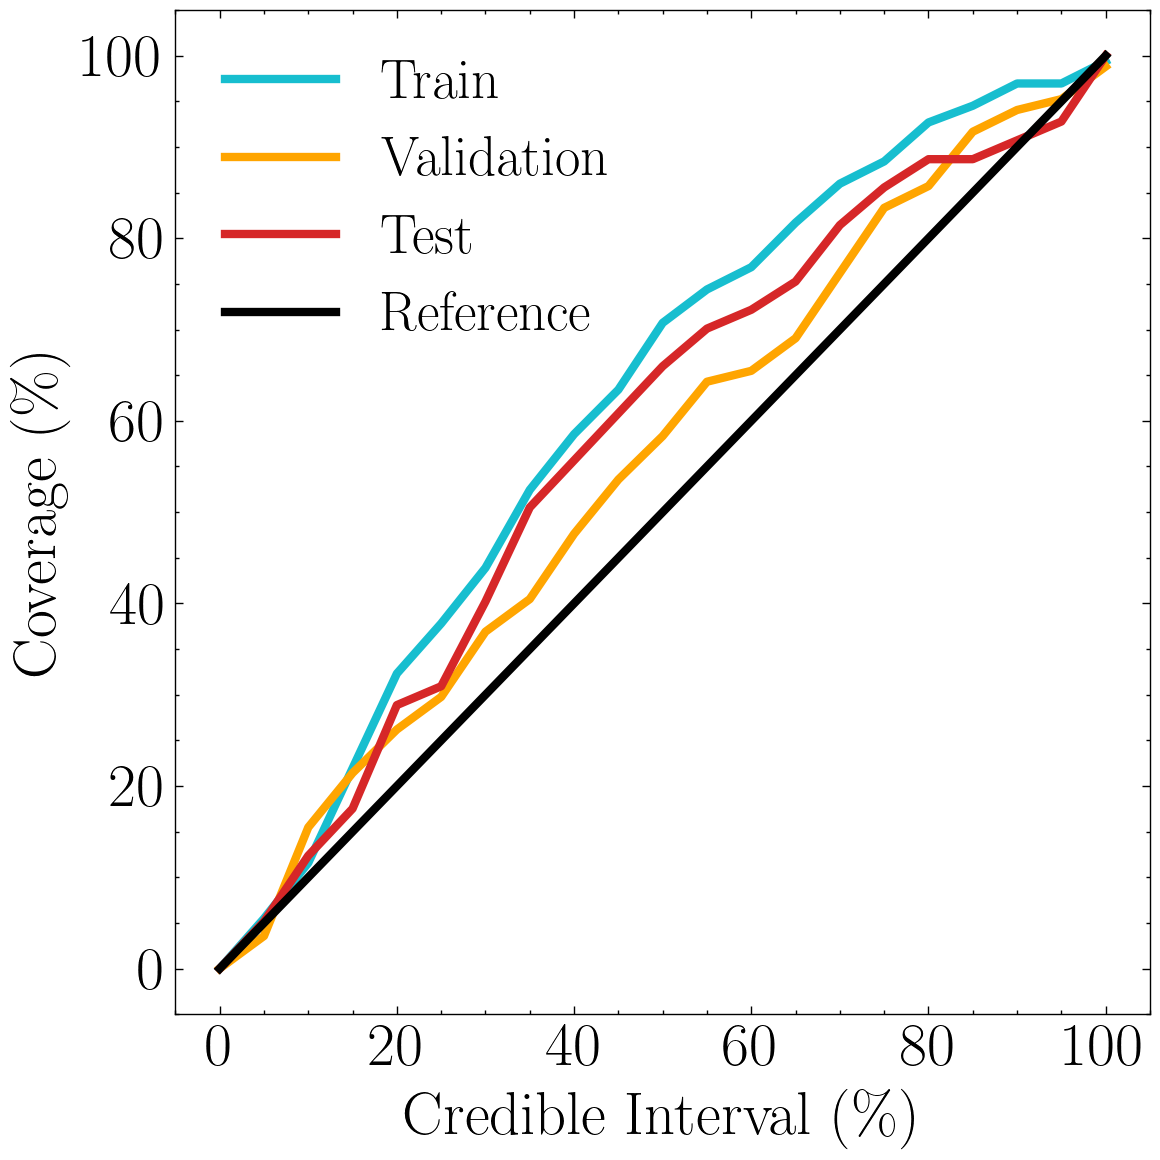

In [56]:
percentiles = np.arange(0,101,5)

coverage_unconstrained_train = coverage(percentiles, rndm_train, models_output_radius_train, 'truth' )
coverage_unconstrained_validation = coverage(percentiles, rndm_val, models_output_radius_validation, 'truth' )
coverage_unconstrained_test = coverage(percentiles, rndm_test, models_output_radius_test, 'truth' )

plot_coverage(
    percentiles,
    coverage_train = coverage_unconstrained_train,
    coverage_validation = coverage_unconstrained_validation,
    coverage_test = coverage_unconstrained_test,
    color_train = color_train,
    color_validation = color_validation,
    color_test = color_test,
    coverage_simplex_train=None,
    coverage_simplex_validation=None,
    coverage_simplex_test=None
)
plt.savefig('../pp_plots/fy_added_models/Coverage_Curve.png')